# DATA ANALYSIS on the Price Runner Aggregate Dataset

### 1.1 IMPORT THE NECESSARY LIBRARIES

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 IMPORT THE NECESSARY LIBRArIES MODULES

In [2]:
import sys
sys.path.append("../")

from src.preprocess import normalize_column_names, run_preprocess
from src.feature_engineering import create_vectorizer,generate_embeddings,run_features
from src.train_model import run_training
from src.similarity_engine import ProductSearchEngine
from src.clustering import run_clustering
from src.pipeline import run_pipeline

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 1.3 LOADING THE REQUIRED DATASET

In [4]:
df = pd.read_csv("../data/raw/pricerunner_aggregate.csv")

##### Using the normalizing function (which exist in src/preprocess)

In [5]:
df = normalize_column_names(df)

In [6]:
df.head()

,product_id,product_title,merchant_id,cluster_id,cluster_label,category_id,category_label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


### 1.4 STATISTICAL DATA ANALYSIS

##### 1.4.1 Size of the dataset

In [7]:
print(f"Number of Rows : {df.shape[0]} \nNumber of Columns : {df.shape[1]}")

Number of Rows : 35311 
Number of Columns : 7


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      35311 non-null  int64 
 1   product_title   35311 non-null  object
 2   merchant_id     35311 non-null  int64 
 3   cluster_id      35311 non-null  int64 
 4   cluster_label   35311 non-null  object
 5   category_id     35311 non-null  int64 
 6   category_label  35311 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.9+ MB


In [9]:
df.describe()

,product_id,merchant_id,cluster_id,category_id
count,35311.000000,35311.000000,35311.000000,35311.000000
mean,26150.800176,120.501883,30110.687633,2618.142930
std,13498.191220,117.045557,18410.265642,3.600708
min,1.000000,1.000000,1.000000,2612.000000
25%,14958.500000,17.000000,6123.000000,2615.000000
50%,27614.000000,75.000000,40630.000000,2619.000000
75%,37508.500000,253.000000,44059.000000,2622.000000
max,47358.000000,371.000000,47525.000000,2623.000000


##### 1.4.2 Checking the null values

In [10]:
df.isnull().sum()

product_id        0
product_title     0
merchant_id       0
cluster_id        0
cluster_label     0
category_id       0
category_label    0
dtype: int64

##### Checking the unique values

In [11]:
df['product_id'].nunique()

35311

In [12]:
df['product_title'].nunique()

30993

In [13]:
df['merchant_id'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  75,  76,  77,  78,  79,  80,
        81,  82,  83,  84,  85,  86, 123, 124,  98, 125, 126, 128, 129,
       130, 131, 132, 119, 133, 134,  91, 135, 136, 137, 138, 139, 140,
       141, 142,  99, 143, 105, 144, 145, 146, 100, 147, 148, 149, 150,
       151, 152, 153, 154, 155, 156, 157, 113, 158, 159, 160, 161, 162,
       163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
       176, 177, 178, 179, 180, 181, 107, 182, 183, 122, 184, 185, 186,
       187, 188, 189, 190, 191, 192, 193, 194, 195, 101, 196, 121,  90,
       197, 198, 199, 200,  74, 201, 247, 248, 249,  88, 250, 25

In [14]:
df['cluster_id'].nunique()

13233

In [15]:
df['cluster_label'].unique()

array(['Apple iPhone 8 Plus 64GB', 'Apple iPhone 7 Plus 32GB',
       'Apple iPhone 7 32GB', ..., 'Smeg FAB28 Pink', 'Candy CRU16.0',
       'Neff K4316'], shape=(12849,), dtype=object)

In [16]:
df['category_id'].unique()

array([2612, 2614, 2615, 2617, 2618, 2619, 2620, 2621, 2622, 2623])

In [17]:
df['category_label'].unique()

array(['Mobile Phones', 'TVs', 'CPUs', 'Digital Cameras', 'Microwaves',
       'Dishwashers', 'Washing Machines', 'Freezers', 'Fridge Freezers',
       'Fridges'], dtype=object)

In [18]:
df.columns

Index(['product_id', 'product_title', 'merchant_id', 'cluster_id',
       'cluster_label', 'category_id', 'category_label'],
      dtype='object')

### 1.5 Fecthing the code from src folder

##### 1.5.1 Generating the embeddings

In [19]:
vec=create_vectorizer()

In [20]:
vec

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'unicode'
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [21]:
preprocess = run_preprocess()

Loading raw dataset...
Dataset shape: (35311, 7)
Normalizing column names...
Handling missing by values...
Cleaning text columns: ['product_title', 'cluster_label', 'category_label']
Creating clean_title column...
Saving processed dataset...
Clean dataset saved: C:\Users\ASUS\Desktop\product_intelligence_engine\Product_intelligence_System\data\processed\products.csv


In [22]:
features=run_features()

Loading dataset...
Dataset Shape: (35311, 8)
Creating TF-IDF features...
Embedding Shape: (35311, 10000)
Number of features: 10000
Saving feature artifacts...
Artifacts saved.
Feature Engineeering complete. 


In [23]:
train=run_training()

Loadoing Dataset...
Loading Embeddings...
Splitting the dataset into two...
Training classifier...
Evaluating model...

Clasification Report:

                  precision    recall  f1-score   support

            cpus       1.00      0.99      1.00       771
 digital cameras       1.00      0.99      1.00       542
     dishwashers       0.89      0.94      0.92       662
        freezers       0.97      0.92      0.94       439
 fridge freezers       0.95      0.92      0.93      1115
         fridges       0.90      0.90      0.90       728
      microwaves       0.96      0.94      0.95       469
   mobile phones       0.96      1.00      0.98       818
             tvs       0.97      0.98      0.98       723
washing machines       0.95      0.94      0.94       796

        accuracy                           0.95      7063
       macro avg       0.95      0.95      0.95      7063
    weighted avg       0.95      0.95      0.95      7063

Saving trained model...
Model saved to : C

In [24]:
cluster=run_clustering()

Loading Dataset...
Loading Embedding...
Embeddding shape: (35311, 10000)
running KMeans Clustering with 187 clusters...
Cluster distribution:
69     3043
133     923
62      788
74      702
82      628
Name: count, dtype: int64
Saving clustering model...
Saving clustered dataset...
Results saved to: C:\Users\ASUS\Desktop\product_intelligence_engine\Product_intelligence_System\models\product_catalog.csv
Clustering complete.


### 1.6 Graph and Maps

##### 1.6.1 Category Analysis

category_label
Fridge Freezers     5501
Mobile Phones       4081
Washing Machines    4044
CPUs                3862
Fridges             3584
TVs                 3564
Dishwashers         3424
Digital Cameras     2697
Microwaves          2342
Freezers            2212
Name: count, dtype: int64


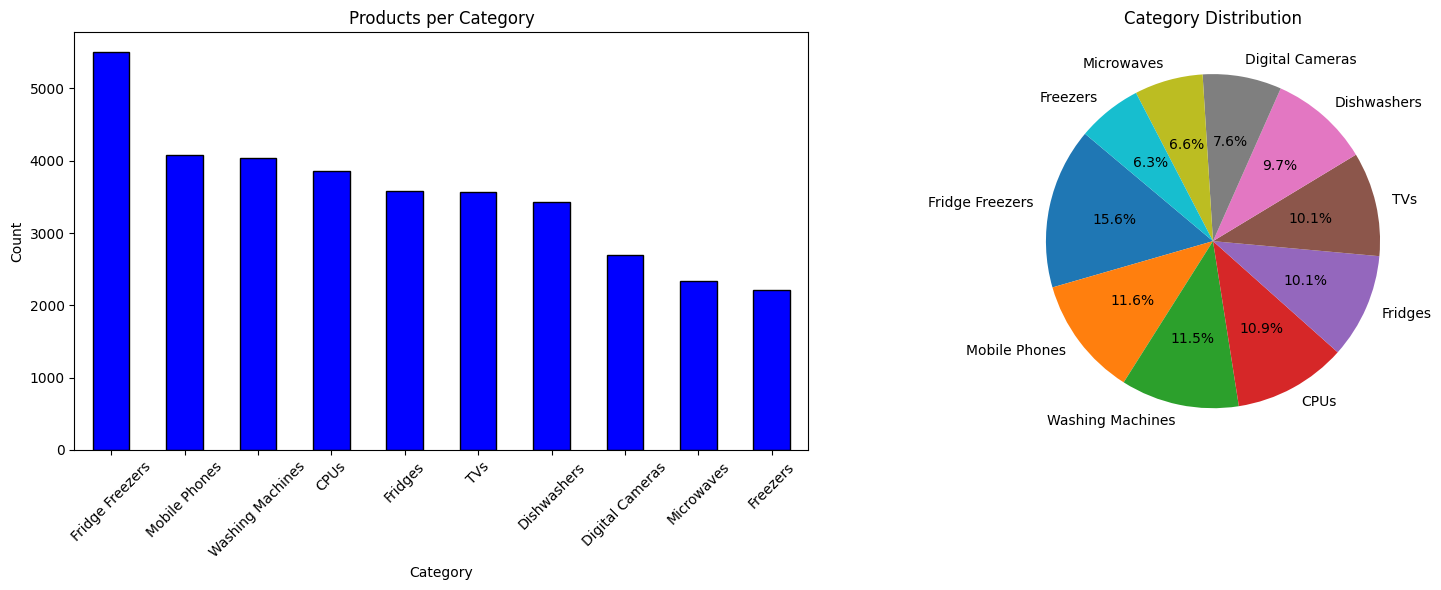


Category ID to Label mapping:
       category_id    category_label
0             2612     Mobile Phones
4081          2614               TVs
7645          2615              CPUs
11507         2617   Digital Cameras
14204         2618        Microwaves
16546         2619       Dishwashers
19970         2620  Washing Machines
24014         2621          Freezers
26226         2622   Fridge Freezers
31727         2623           Fridges


In [25]:
category_counts = df['category_label'].value_counts()
print(category_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# bar chart
category_counts.plot(kind='bar', ax=axes[0], color='blue', edgecolor='black')
axes[0].set_title('Products per Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# pie chart
axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Category Distribution')

plt.tight_layout()
plt.show()

# category id vs label mapping
print("\nCategory ID to Label mapping:")
print(df[['category_id', 'category_label']].drop_duplicates().sort_values('category_id'))

##### 1.6.2 Merchant Analysis

Total unique merchants: 306
Avg products per merchant: 115.4


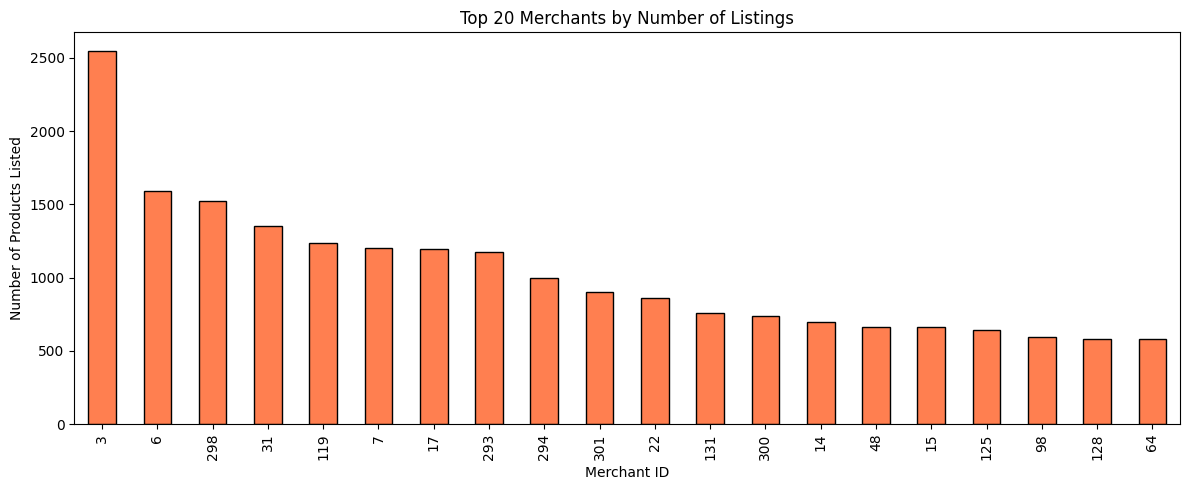


Merchants listing in multiple categories:
category_label
2     32
6     29
4     28
7     23
3     22
5     16
8      7
9      6
10     4
Name: count, dtype: int64


In [26]:
print("Total unique merchants:", df['merchant_id'].nunique())
print("Avg products per merchant:", round(df.groupby('merchant_id').size().mean(), 2))

merchant_counts = df.groupby('merchant_id').size().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
merchant_counts.head(20).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 20 Merchants by Number of Listings')
plt.xlabel('Merchant ID')
plt.ylabel('Number of Products Listed')
plt.tight_layout()
plt.show()

# merchants listing across multiple categories
merchant_categories = df.groupby('merchant_id')['category_label'].nunique()
print("\nMerchants listing in multiple categories:")
print(merchant_categories[merchant_categories > 1].value_counts())

##### 1.6.3 Cluster Analysis

Total unique clusters: 13233

Cluster size stats:
count    13233.000000
mean         2.668405
std          2.473239
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         27.000000
dtype: float64

Largest clusters:
cluster_id
38848    27
38849    24
4419     24
1        23
38850    23
4425     23
4420     23
3        22
4        22
2        22
dtype: int64

Single product clusters: 5374


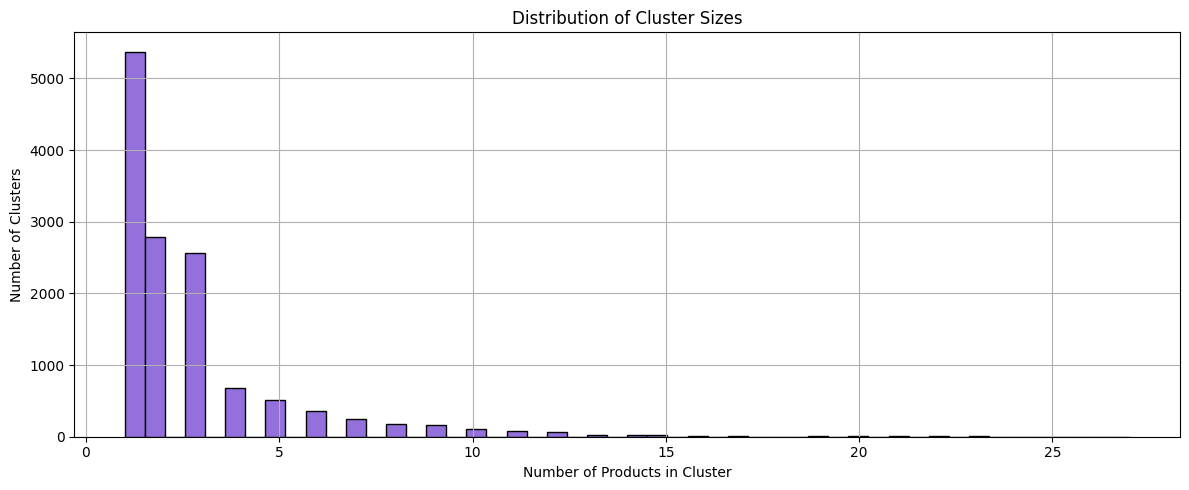


Clusters per category:
category_label
Fridge Freezers     1998
CPUs                1975
Mobile Phones       1704
Fridges             1373
Dishwashers         1368
TVs                 1280
Washing Machines    1277
Microwaves           785
Freezers             760
Digital Cameras      713
Name: cluster_id, dtype: int64


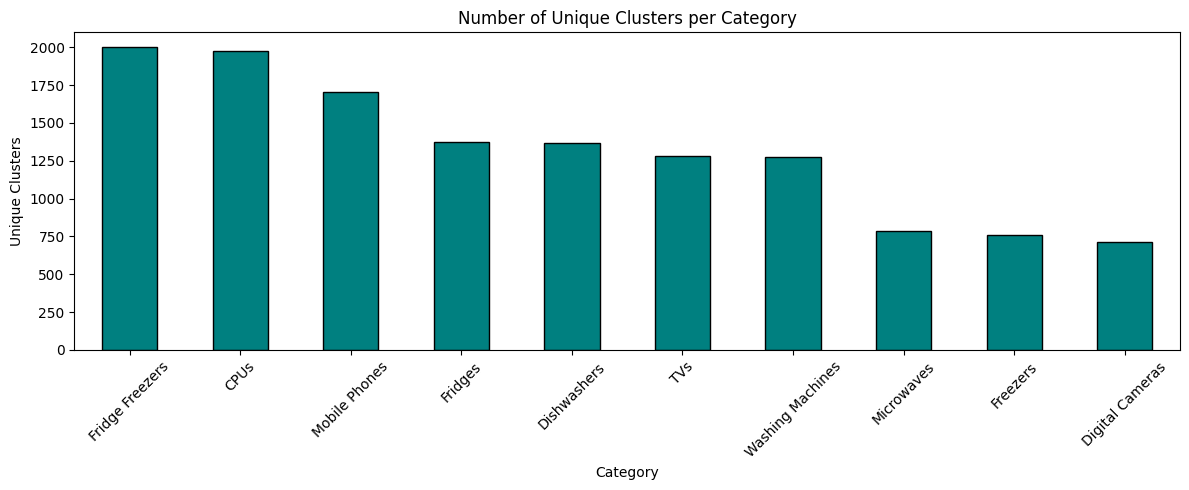

In [27]:
print("Total unique clusters:", df['cluster_id'].nunique())

cluster_sizes = df.groupby('cluster_id').size()
print("\nCluster size stats:")
print(cluster_sizes.describe())

print("\nLargest clusters:")
print(cluster_sizes.sort_values(ascending=False).head(10))

print("\nSingle product clusters:", (cluster_sizes == 1).sum())

plt.figure(figsize=(12, 5))
cluster_sizes.hist(bins=50, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Cluster Sizes')
plt.xlabel('Number of Products in Cluster')
plt.ylabel('Number of Clusters')
plt.tight_layout()
plt.show()

# clusters per category
clusters_per_cat = df.groupby('category_label')['cluster_id'].nunique().sort_values(ascending=False)
print("\nClusters per category:")
print(clusters_per_cat)

plt.figure(figsize=(12, 5))
clusters_per_cat.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Unique Clusters per Category')
plt.xlabel('Category')
plt.ylabel('Unique Clusters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1.6.4 Duplicate and overlap analysis

##### 1.6.5 Product Title Analysis

Title character length stats:
count    35311.000000
mean        52.982215
std         22.447138
min          5.000000
25%         38.000000
50%         52.000000
75%         65.000000
max        200.000000
Name: title_char_length, dtype: float64

Title word count stats:
count    35311.000000
mean         8.665911
std          4.166677
min          1.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         37.000000
Name: title_word_count, dtype: float64

Avg word count per category:
category_label
CPUs                12.42
TVs                 10.25
Digital Cameras      9.62
Mobile Phones        8.55
Fridge Freezers      8.18
Washing Machines     7.82
Microwaves           7.65
Fridges              7.49
Freezers             7.21
Dishwashers          6.81
Name: title_word_count, dtype: float64


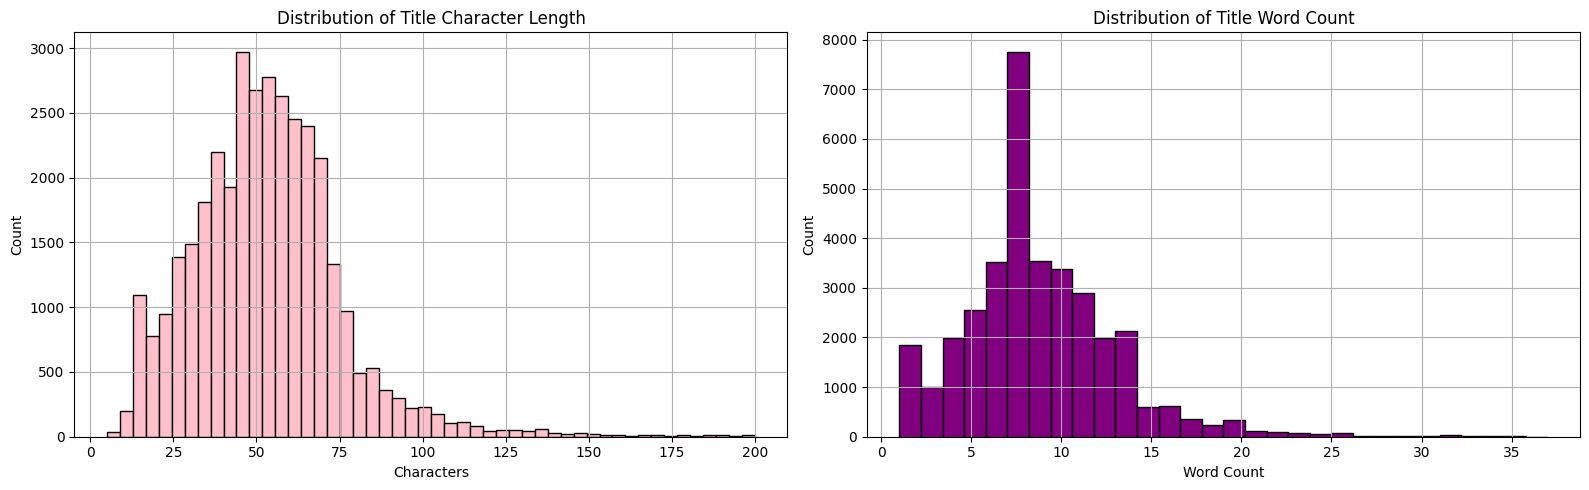

In [28]:
df['title_char_length'] = df['product_title'].apply(len)
df['title_word_count'] = df['product_title'].apply(lambda x: len(str(x).split()))

print("Title character length stats:")
print(df['title_char_length'].describe())

print("\nTitle word count stats:")
print(df['title_word_count'].describe())

# by category
print("\nAvg word count per category:")
print(df.groupby('category_label')['title_word_count'].mean().sort_values(ascending=False).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['title_char_length'].hist(bins=50, ax=axes[0], color='pink', edgecolor='black')
axes[0].set_title('Distribution of Title Character Length')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

df['title_word_count'].hist(bins=30, ax=axes[1], color='purple', edgecolor='black')
axes[1].set_title('Distribution of Title Word Count')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

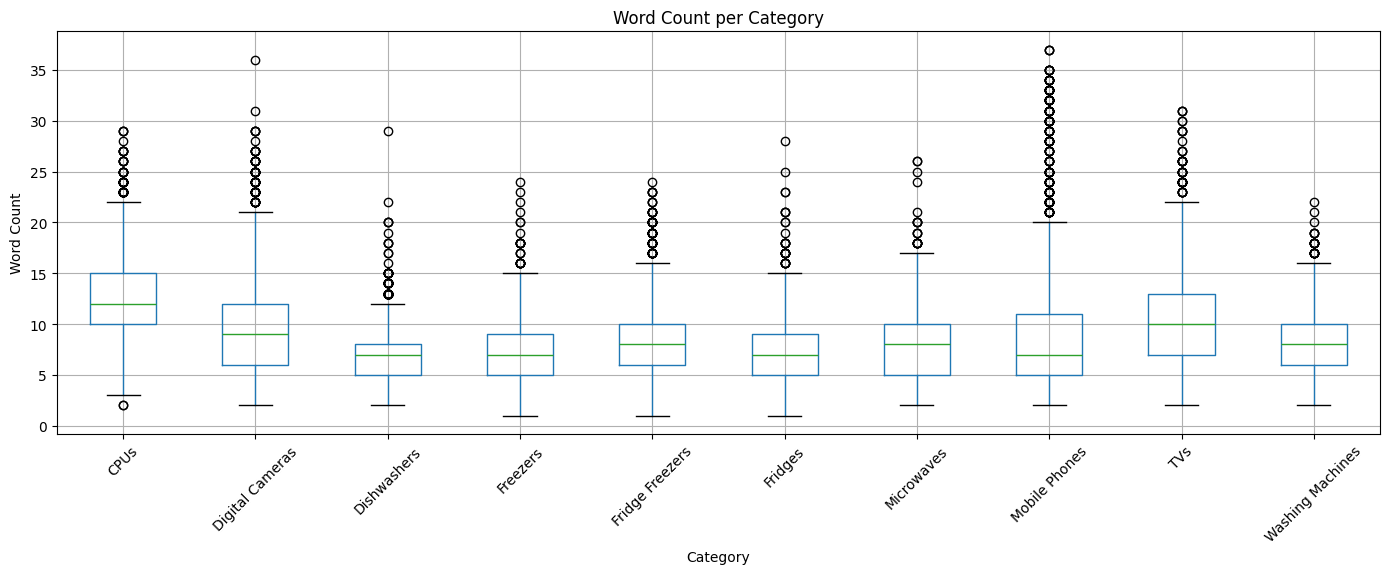


Shortest title: lg q6
Longest title: ulefone armor2 ip68 rugged unlocked 4g cellphone smartphone mobilephone 5 inch fhd screen 6gb 64gb 8 core powerful helio p25 2.6ghz cpu super power savery 4700mah battery best pe 2.0 fast charge water


In [29]:
# boxplot of word count by category
plt.figure(figsize=(14, 6))
df.boxplot(column='title_word_count', by='category_label', figsize=(14, 6))
plt.title('Word Count per Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# shortest and longest titles
print("\nShortest title:", df.loc[df['title_char_length'].idxmin(), 'product_title'])
print("Longest title:", df.loc[df['title_char_length'].idxmax(), 'product_title'])

##### 1.6.6 Category vs Cluster Analysis

                  total_products  unique_clusters  avg_cluster_size
category_label                                                     
CPUs                        3862             1975              1.96
Digital Cameras             2697              713              3.78
Dishwashers                 3424             1368              2.50
Freezers                    2212              760              2.91
Fridge Freezers             5501             1998              2.75
Fridges                     3584             1373              2.61
Microwaves                  2342              785              2.98
Mobile Phones               4081             1704              2.39
TVs                         3564             1280              2.78
Washing Machines            4044             1277              3.17


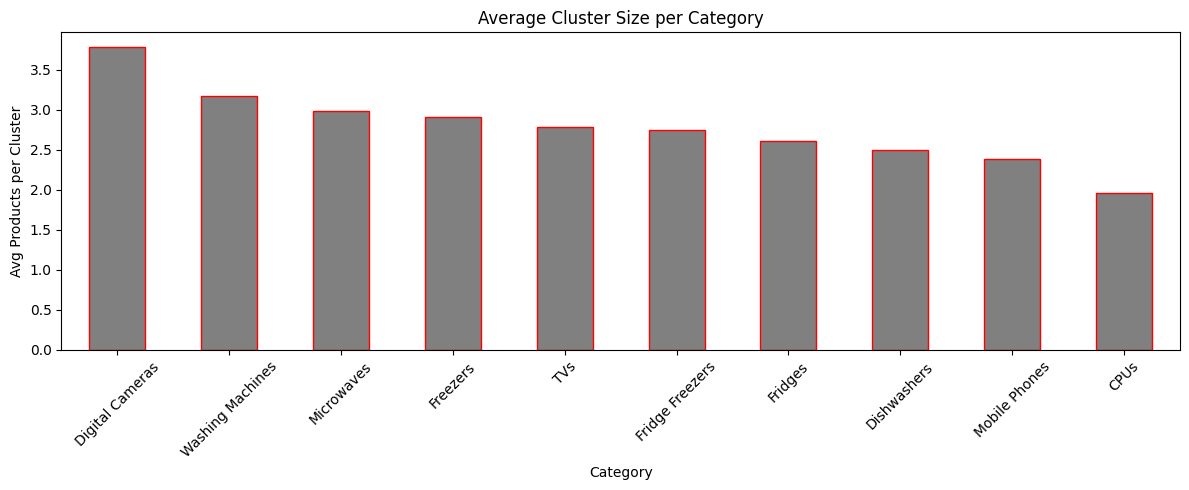

In [30]:
cat_cluster = df.groupby('category_label').agg(
    total_products=('product_id', 'count'),
    unique_clusters=('cluster_id', 'nunique'),
    avg_cluster_size=('cluster_id', lambda x: len(x) / x.nunique())
).round(2)

print(cat_cluster)

plt.figure(figsize=(12, 5))
cat_cluster['avg_cluster_size'].sort_values(ascending=False).plot(kind='bar', color='grey', edgecolor='red')
plt.title('Average Cluster Size per Category')
plt.xlabel('Category')
plt.ylabel('Avg Products per Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Titles above 99th percentile (128.0 chars):
                                          product_title category_label  \
107   apple iphone x smartphone 4g lte advanced 64 g...  Mobile Phones   
119   samsung galaxy s8 single sim 64gb android uk v...  Mobile Phones   
450   sony xperia xz1 compact 4.6 inch hd screen and...  Mobile Phones   
451   sony xperia xz1 compact 4.6 inch hd screen and...  Mobile Phones   
769   cat 77333s60outdoor 11.9cm 4.7inches smartphon...  Mobile Phones   
964   samsung galaxy a6 smartphone 14 25 cm 5 6 zoll...  Mobile Phones   
1007  apple iphone 8 plus 5.5 inch multi touch retin...  Mobile Phones   
1008  apple iphone 8 plus 5.5 inch multi touch retin...  Mobile Phones   
1117  apple iphone 8 4.7 inch multi touch retina hd ...  Mobile Phones   
1213  doro primo 413 2.4zoll 115g rot 2.4 320 x 240 ...  Mobile Phones   

      title_char_length  
107                 148  
119                 160  
450                 130  
451                 130  
769        

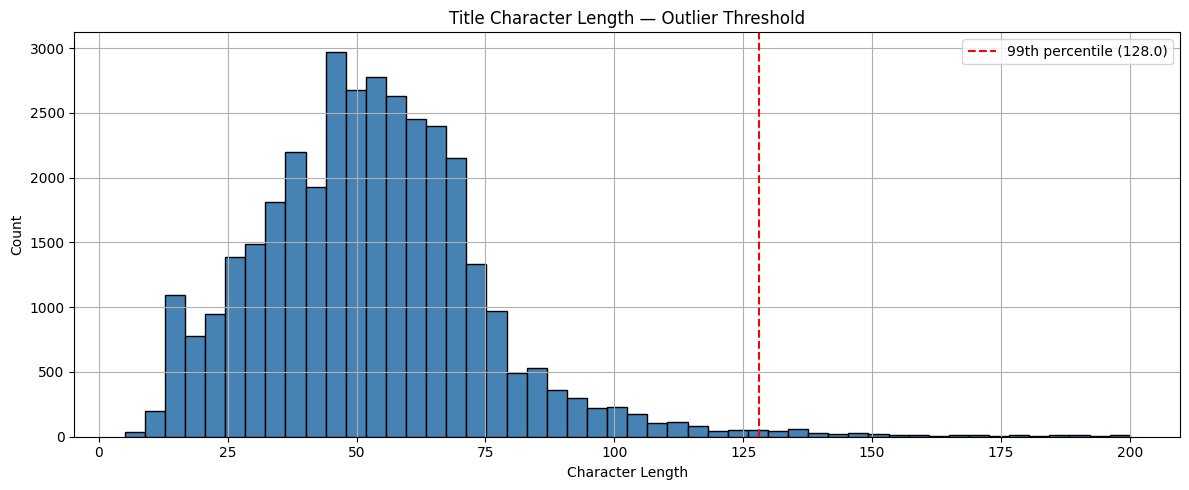


Clusters above 99th percentile size (12.0):
cluster_id
38848    27
4419     24
38849    24
4425     23
4420     23
1        23
38850    23
4423     22
3        22
2        22
dtype: int64


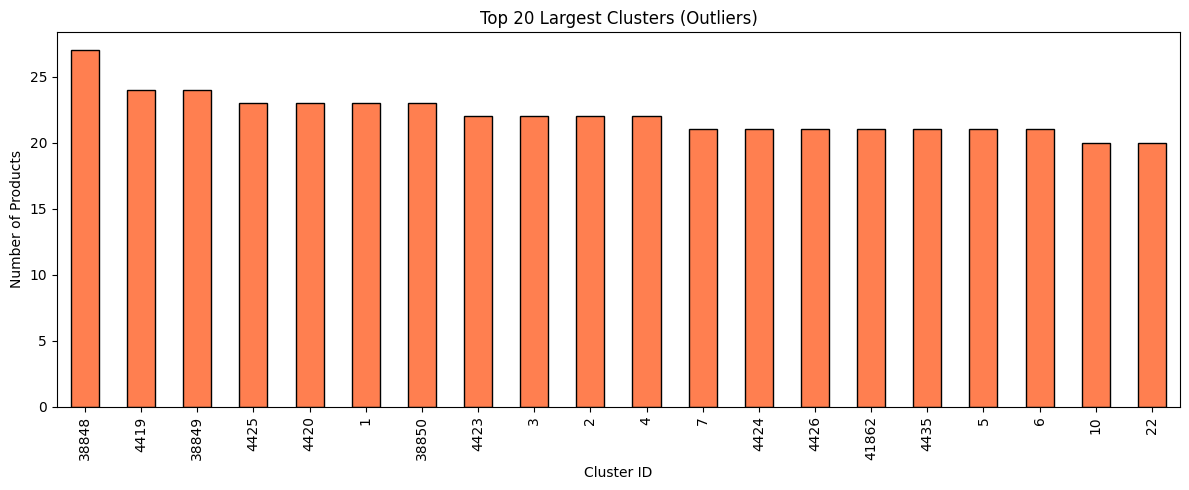


Merchants above 99th percentile listings:
merchant_id
3      2547
6      1591
298    1523
31     1350
dtype: int64


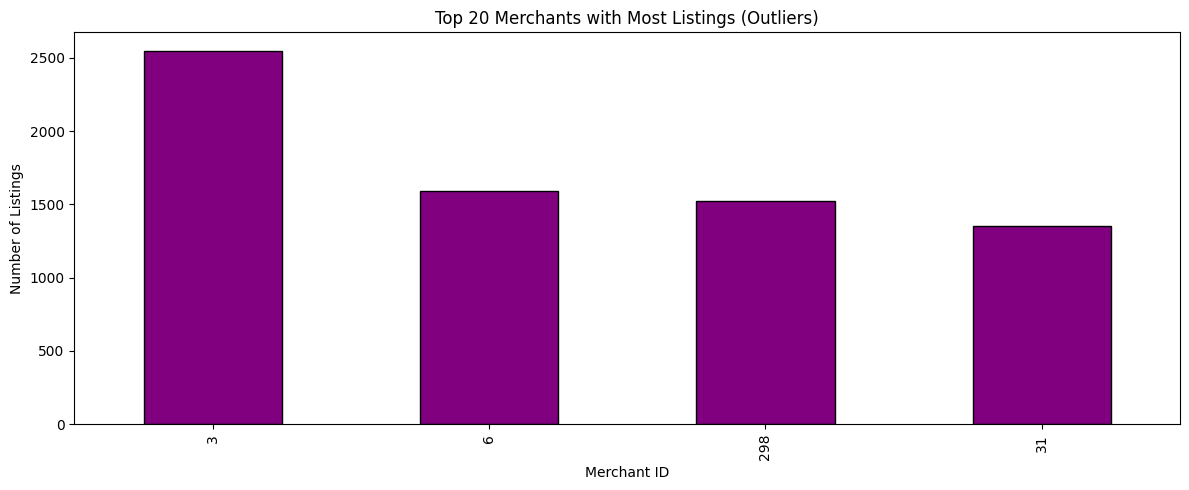

In [35]:
# long titles
q99 = df['title_char_length'].quantile(0.99)
long_titles = df[df['title_char_length'] > q99][['product_title', 'category_label', 'title_char_length']]
print(f"Titles above 99th percentile ({q99} chars):")
print(long_titles.head(10))

plt.figure(figsize=(12, 5))
df['title_char_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.axvline(q99, color='red', linestyle='--', label=f'99th percentile ({q99})')
plt.title('Title Character Length — Outlier Threshold')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# very large clusters
large_clusters = cluster_sizes[cluster_sizes > cluster_sizes.quantile(0.99)]
print(f"\nClusters above 99th percentile size ({cluster_sizes.quantile(0.99)}):")
print(large_clusters.sort_values(ascending=False).head(10))

plt.figure(figsize=(12, 5))
large_clusters.sort_values(ascending=False).head(20).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 20 Largest Clusters (Outliers)')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

# merchants with unusually high listings
high_merchants = merchant_counts[merchant_counts > merchant_counts.quantile(0.99)]
print(f"\nMerchants above 99th percentile listings:")
print(high_merchants.head(10))

plt.figure(figsize=(12, 5))
high_merchants.head(20).plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 20 Merchants with Most Listings (Outliers)')
plt.xlabel('Merchant ID')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

##### 1.6.7 Correlation & Distribution

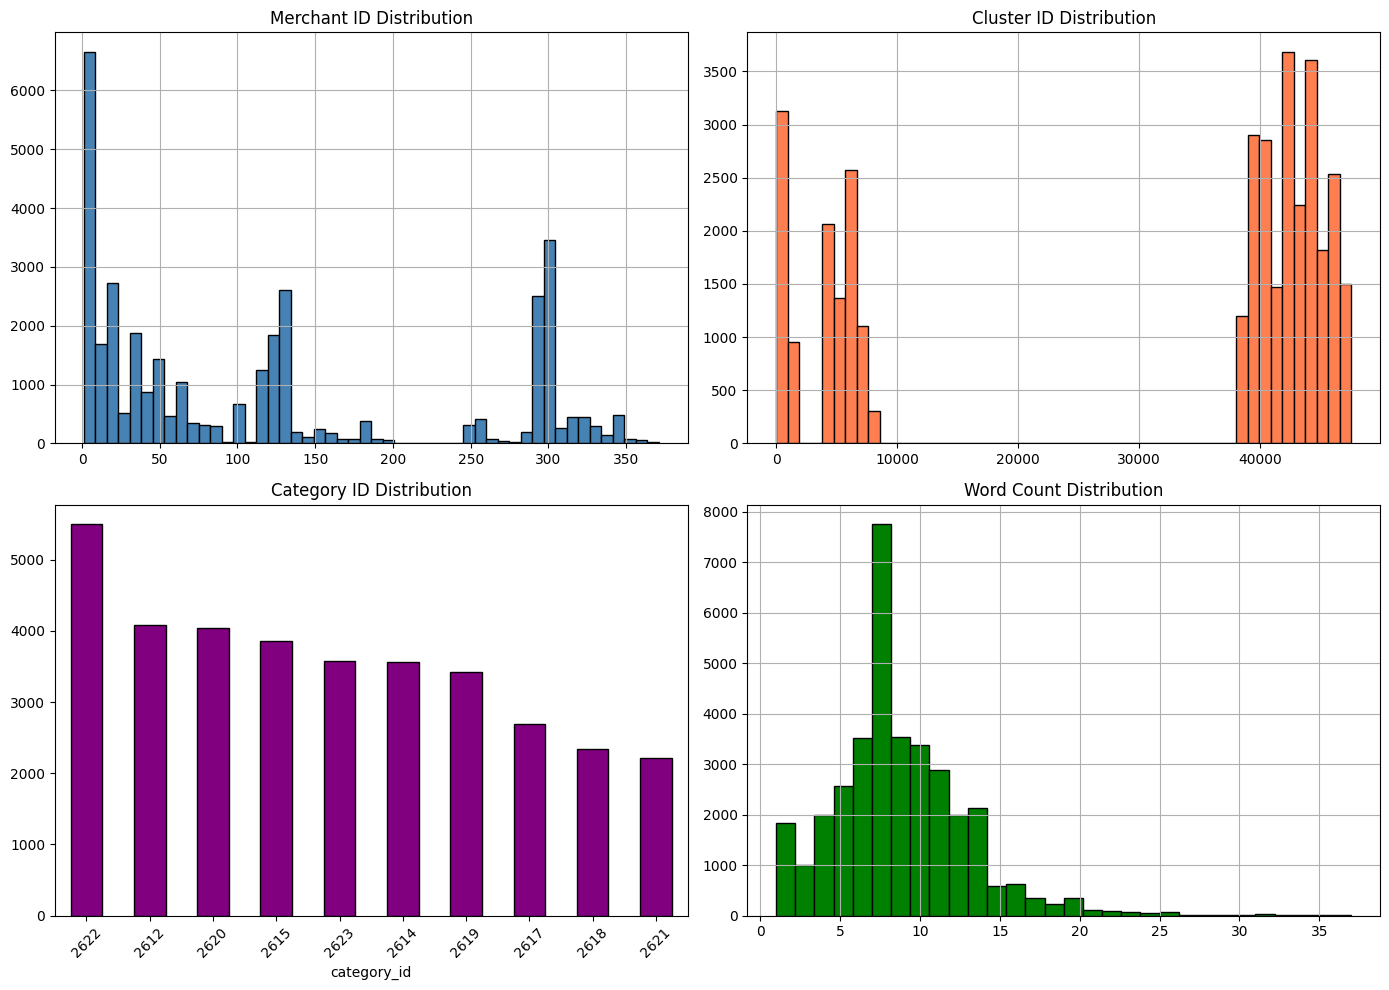

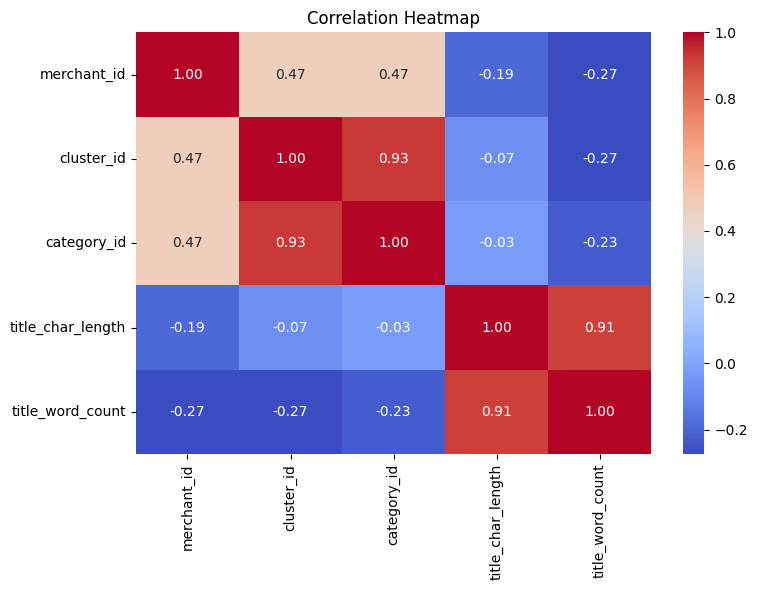

In [36]:
# numerical columns distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['merchant_id'].hist(bins=50, ax=axes[0][0], color='steelblue', edgecolor='black')
axes[0][0].set_title('Merchant ID Distribution')

df['cluster_id'].hist(bins=50, ax=axes[0][1], color='coral', edgecolor='black')
axes[0][1].set_title('Cluster ID Distribution')

df['category_id'].value_counts().plot(kind='bar', ax=axes[1][0], color='purple', edgecolor='black')
axes[1][0].set_title('Category ID Distribution')
axes[1][0].tick_params(axis='x', rotation=45)

df['title_word_count'].hist(bins=30, ax=axes[1][1], color='green', edgecolor='black')
axes[1][1].set_title('Word Count Distribution')

plt.tight_layout()
plt.show()

# correlation on numerical cols
corr = df[['merchant_id', 'cluster_id', 'category_id', 'title_char_length', 'title_word_count']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()